# Parameters

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.utils.parameters import (
    mcwf_dt_from_scales,
    omega_c,
    scaled_N_Gamma,
)
from parser.moments import MomentSeries, SimulationMetadata

%reload_ext autoreload
%autoreload 2

output_dir = repo_root / "output"

### Parameters

In [2]:
# common fixed
Gamma = 1; num_snapshots=500
# param
dN = 0
Ni = [20,20]
omega_i = [0.7]
ntraj = 1000
# Model and parameters
Omega_factor = 0.1
Omega0 = scaled_N_Gamma(Omega_factor, sum(Ni), Gamma)
delta_factor = 0.01
delta0 = scaled_N_Gamma(delta_factor, sum(Ni), Gamma)
dt = mcwf_dt_from_scales(Omega0, delta0, sum(Ni), Gamma)
# dt = 1e-3
# protocol durations
T1 = 10.0
T2 = 100.0
T3 = 10.0

simulation_metadata = SimulationMetadata(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    Omega0=Omega0,
    delta0=delta0,
    T1=T1,
    T2=T2,
    T3=T3,
)

Omega_c = omega_c(sum(Ni) // 2, Gamma)
print(f"Omega0 = {Omega0}")
print(f"Omega ratio = {Omega0 / Omega_c}")
print(f"delta0 = {delta0}")
print(f"dt = {dt}")


Omega0 = 4.0
Omega ratio = 0.4
delta0 = 0.4
dt = 0.0025


### Mean-field Equations

In [3]:
from solvers.mfe import compute_mfe_j_moments, solve_mfe
from parser.mfe import MFESolverParameters

# moment initialization
mfe_moments = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata,
)

# Define method parameters and solve using mean-field equations
mfe_parameters = MFESolverParameters(
    Ni=simulation_metadata.Ni,
    omega_i=simulation_metadata.omega_groups,
    Gamma=simulation_metadata.Gamma,
    phases=simulation_metadata.phases,
)
mfe_result = solve_mfe(
    mfe_parameters,
    t_eval=mfe_moments.t,
)

# compute moments
mfe_moments.J = compute_mfe_j_moments(mfe_result)

### Monte-Carlo Wave Function

In [4]:
from parser.mcwf import MCWFSolverParameters
from solvers.mcwf.ensamble_sim import run_trajectory_ensemble
from solvers.mcwf.j_moments import compute_mcwf_j_moments
from post_analysis import compute_mfe_residuals

# moment initialization
mcwf_moments = MomentSeries(
    num_snapshots=num_snapshots,
    metadata=simulation_metadata,
)

# Define method parameters and simulate using Monte-Carlo wave function method
mcwf_parameters = MCWFSolverParameters(
    Ni=simulation_metadata.Ni,
    omega_i=simulation_metadata.omega_groups,
    Gamma=simulation_metadata.Gamma,
    phases=simulation_metadata.phases,
    dN=dN,
    sector_distribution="binomial",
    dt=dt,
    shifted_jump_operator=True,
)
mcwf_ensemble = run_trajectory_ensemble(
    mcwf_parameters,
    t_eval=mcwf_moments.t,
    seed=1234,
    ntraj=ntraj,
    n_processes=-1,
    )

# compute moments
mcwf_moments.J = compute_mcwf_j_moments(
    mcwf_ensemble,
    n_processes=-1,
)

# mfe resiudals
mcwf_moments.mfe_residuals = compute_mfe_residuals(
    mcwf_moments.J,
    metadata=mcwf_moments.metadata,
)

/Users/ashar/.pyenv/versions/cavity-OAT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
simulate trajectories: 100%|██████████| 1000/1000 [01:47<00:00,  9.34it/s]

Simulation step summary (avg per trajectory): total steps=48456.32, steps without precompute=552.32



compute_mcwf_j_moments: 100%|██████████| 1000/1000 [00:07<00:00, 125.78it/s]


### Plotting

Residual L1 norm
Phase 1 - end: 2.576e-02, min: 0.000e+00
Phase 2 - end: 3.216e-03, min: 1.553e-03
Phase 3 - end: 1.073e-06, min: 1.073e-06


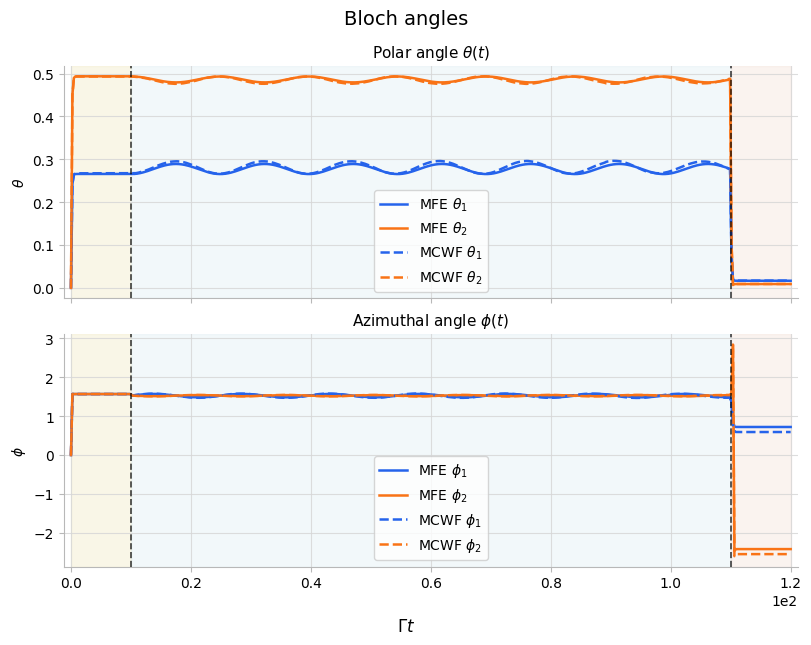

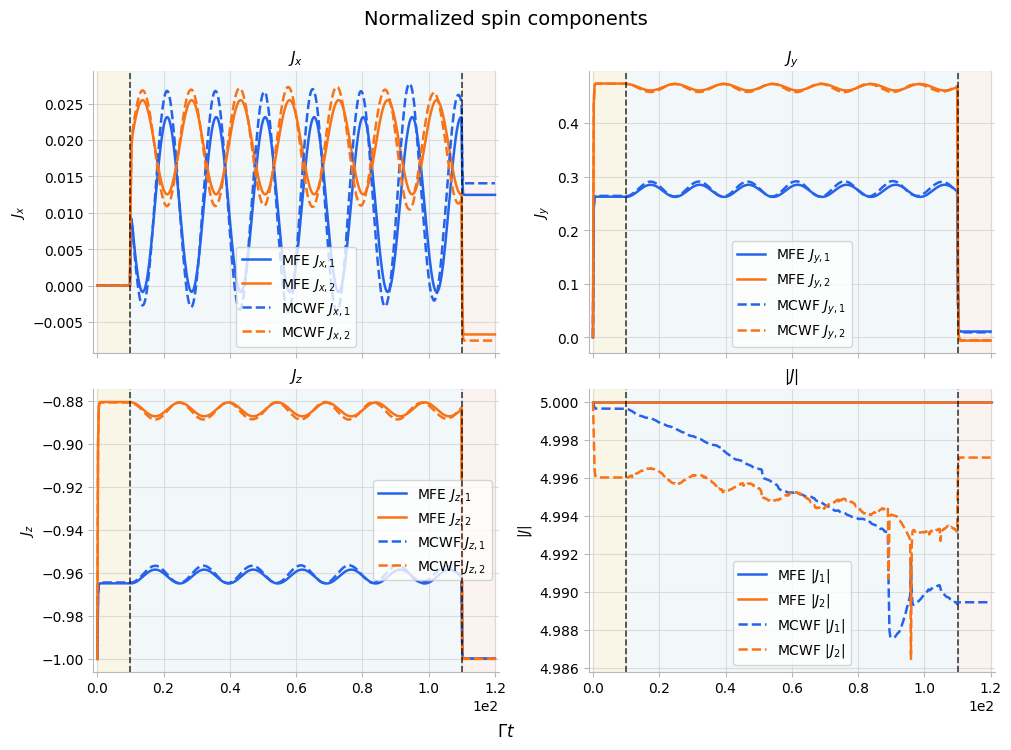

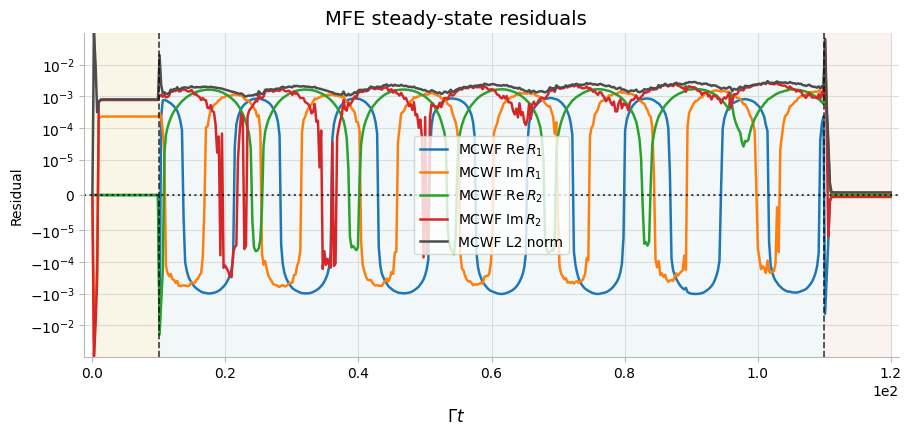

In [7]:
from common.plotting import (
    plot_bloch_angles,
    plot_spin_components,
    plot_mfe_residuals,
)


fig, axes = plot_bloch_angles(
    mfe_moments.J,
    phases=mfe_moments.metadata.phases,
    label="MFE",
    colour_index=0,
    linestyle="-",
)
fig, axes = plot_bloch_angles(
    mcwf_moments.J,
    phases=mcwf_moments.metadata.phases,
    label="MCWF",
    colour_index=0,
    linestyle="--",
    axes=axes,
    output_path=f"{output_dir}/finite_size_effects/angles_N32.png",
)


normalized=True
fig, axes = plot_spin_components(
    mfe_moments.J,
    normalized=normalized,
    phases=mfe_moments.metadata.phases,
    label="MFE",
    colour_index=0,
    linestyle="-",
)
fig, axes = plot_spin_components(
    mcwf_moments.J,
    normalized=normalized,
    phases=mcwf_moments.metadata.phases,
    label="MCWF",
    colour_index=0,
    linestyle="--",
    axes=axes,
    output_path=f"{output_dir}/finite_size_effects/spins_N32.png",
)

# plot mfe residuals
fig, axes = plot_mfe_residuals(
    mcwf_moments.mfe_residuals,
    phases=mcwf_moments.metadata.phases,
    label="MCWF",
    colour_index=0,
    linestyle="-",
    symlog=True,
    output_path=f"{output_dir}/finite_size_effects/mfe_residuals_N32.png",
)
